# Imports

In [1]:
import pickle
from collections import Counter
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from beatmap_classifier.classifier.utils_training import (get_data, get_additional_features, pad_sequences_pt,
                                                          train_and_evaluate, plot_training_history, load_pytorch_models)
from beatmap_classifier.classifier.augment_faster import augment_dataset, extract_movement_features_from_X

# Model Testing

Go run test_model.py

# Initializing some Data

In [2]:
TOURNAMENT_MODS = {
    "nm1": "NM",
    "nm2": "NM",
    "nm3": "NM",
    "nm4": "NM",
    "nm5": "NM",
    "nm6": "NM",
    "hd1": "HD",
    "hd2": "HD",
    "hd3": "HD",
    "hr1": "HR",
    "hr2": "HR",
    "hr3": "HR",
    "dt1": "DT",
    "dt2_and_dt3": "DT",
    "dt4": "DT",
    "tiebreaker": "NM",
}

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = 'beatmaps.db'

X, y, beatmap_ids = get_data(db_path)
raw_additional_features, normalized_additional_features = get_additional_features(db_path, y, beatmap_ids)

Max Vector Length: 500.0
Max Time Diff: 86087.0
Tournament-labeled beatmaps: 3908
Max Vector Count: 6309
Original beatmaps: 3908


In [4]:
# Get the mod associated with each tournament label
mods_flattened = [
    TOURNAMENT_MODS[label]
    if TOURNAMENT_MODS[label]
    else "NM"
    for label in y
]

raw_additional_features_array = np.array([
    raw_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

normalized_additional_features_array = np.array([
    normalized_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

In [5]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    beatmap_ids_train,
    beatmap_ids_test,
) = train_test_split(
    X,
    y,
    beatmap_ids,
    test_size=0.2,
    random_state=42,
)

print(f"Final train size: {len(X_train)}")
print(f"Final test size:  {len(X_test)}")

Final train size: 3126
Final test size:  782


In [6]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_numerical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_numerical = torch.tensor(y_test_numerical, dtype=torch.long)

# Pad sequences
sequence_lengths = np.array([len(seq) for seq in X])
max_length = int(np.percentile(sequence_lengths, 99))
max_length = 2 ** int(np.ceil(np.log2(max_length)))
max_length = min(max_length, 4096)

print(f"Using max sequence length: {max_length}")

X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)

X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print("Before metadata:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Using max sequence length: 4096
Before metadata:
X_train: torch.Size([3126, 4096, 8])
X_test:  torch.Size([782, 4096, 8])


In [45]:
class_counts = Counter(y_train_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

print(dict(enumerate(label_encoder.classes_)))

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [9]:
# 1. Extract geometric summary vectors for each row in X_train and X_test
movement_features_train = np.array(
    [extract_movement_features_from_X(X_train[i]) for i in range(len(X_train))],
    dtype=np.float32,
)

movement_features_test = np.array(
    [extract_movement_features_from_X(X_test[i]) for i in range(len(X_test))],
    dtype=np.float32,
)

# 2. Extract SQLite metadata features corresponding to train/test IDs
sql_features_train = np.array(
    [
        normalized_additional_features[(b_id, "NM")]
        for b_id in beatmap_ids_train
    ],
    dtype=np.float32,
)

sql_features_test = np.array(
    [normalized_additional_features[(b_id, "NM")] for b_id in beatmap_ids_test],
    dtype=np.float32,
)

# 3. Concatenate (SQL metadata + Movement geometric summary)
X_additional_train = np.hstack(
    [sql_features_train, movement_features_train]
)
X_additional_test = np.hstack(
    [sql_features_test, movement_features_test]
)

print(f"Full meta tabular train shape: {X_additional_train.shape}")
print(f"Full meta tabular test shape:  {X_additional_test.shape}")

Full meta tabular train shape: (3126, 20)
Full meta tabular test shape:  (782, 20)


# CNN Model (SKIP TO XGBOOST IF DESIRED)

--- Training Meta Fold 1/5 ---
Original samples: 2500 -> Augmented total: 10000
Epoch 1/30 - loss: 1.2535 - acc: 0.5389 - val_loss: 0.9569 - val_acc: 0.7268
Epoch 2/30 - loss: 1.0479 - acc: 0.6748 - val_loss: 0.9278 - val_acc: 0.7540
Epoch 3/30 - loss: 0.9926 - acc: 0.7063 - val_loss: 0.9210 - val_acc: 0.7316
Epoch 4/30 - loss: 0.9479 - acc: 0.7323 - val_loss: 0.9343 - val_acc: 0.7444
Epoch 5/30 - loss: 0.9008 - acc: 0.7654 - val_loss: 0.7752 - val_acc: 0.8403
Epoch 6/30 - loss: 0.8756 - acc: 0.7846 - val_loss: 0.7580 - val_acc: 0.8450
Epoch 7/30 - loss: 0.8555 - acc: 0.7978 - val_loss: 0.7398 - val_acc: 0.8482
Epoch 8/30 - loss: 0.8256 - acc: 0.8138 - val_loss: 0.7699 - val_acc: 0.8291
Epoch 9/30 - loss: 0.8014 - acc: 0.8263 - val_loss: 0.7947 - val_acc: 0.8067
Epoch 10/30 - loss: 0.7912 - acc: 0.8335 - val_loss: 0.7107 - val_acc: 0.8610
Epoch 11/30 - loss: 0.7765 - acc: 0.8414 - val_loss: 0.7346 - val_acc: 0.8514
Epoch 12/30 - loss: 0.7629 - acc: 0.8461 - val_loss: 0.8492 - val_acc: 

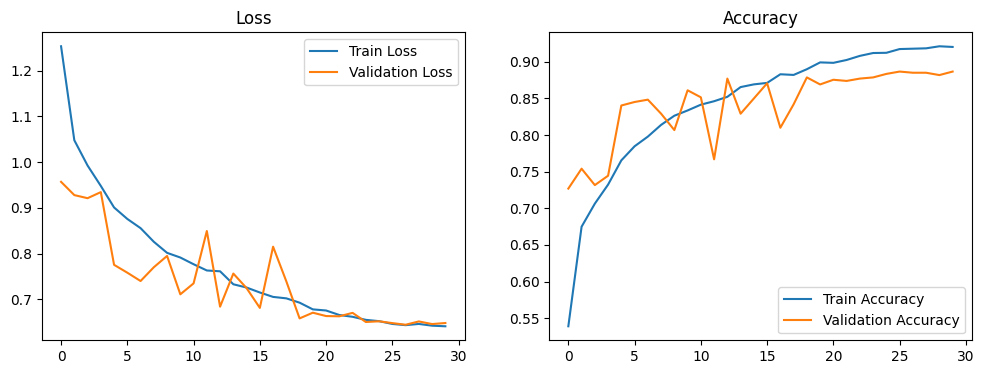

--- Training Meta Fold 2/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.2461 - acc: 0.5524 - val_loss: 0.9576 - val_acc: 0.7344
Epoch 2/30 - loss: 1.0142 - acc: 0.6936 - val_loss: 0.8692 - val_acc: 0.7552
Epoch 3/30 - loss: 0.9447 - acc: 0.7358 - val_loss: 0.8560 - val_acc: 0.7776
Epoch 4/30 - loss: 0.9099 - acc: 0.7615 - val_loss: 0.7762 - val_acc: 0.8464
Epoch 5/30 - loss: 0.8653 - acc: 0.7928 - val_loss: 0.7983 - val_acc: 0.8112
Epoch 6/30 - loss: 0.8589 - acc: 0.7937 - val_loss: 0.7246 - val_acc: 0.8544
Epoch 7/30 - loss: 0.8280 - acc: 0.8101 - val_loss: 0.7611 - val_acc: 0.8320
Epoch 8/30 - loss: 0.8103 - acc: 0.8232 - val_loss: 0.7282 - val_acc: 0.8592
Epoch 9/30 - loss: 0.8056 - acc: 0.8244 - val_loss: 0.7052 - val_acc: 0.8656
Epoch 10/30 - loss: 0.7887 - acc: 0.8390 - val_loss: 0.7035 - val_acc: 0.8688
Epoch 11/30 - loss: 0.7679 - acc: 0.8449 - val_loss: 0.6724 - val_acc: 0.8816
Epoch 12/30 - loss: 0.7571 - acc: 0.8540 - val_loss: 0.7182 - val_acc: 

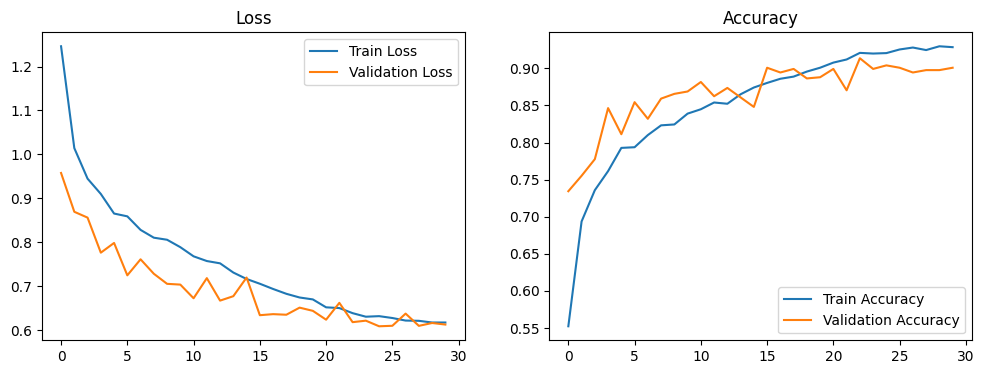

--- Training Meta Fold 3/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.2354 - acc: 0.5443 - val_loss: 0.9986 - val_acc: 0.6768
Epoch 2/30 - loss: 1.0120 - acc: 0.6944 - val_loss: 0.8672 - val_acc: 0.7760
Epoch 3/30 - loss: 0.9544 - acc: 0.7342 - val_loss: 0.8818 - val_acc: 0.7872
Epoch 4/30 - loss: 0.8997 - acc: 0.7768 - val_loss: 0.7920 - val_acc: 0.8192
Epoch 5/30 - loss: 0.8525 - acc: 0.8015 - val_loss: 0.7765 - val_acc: 0.8400
Epoch 6/30 - loss: 0.8337 - acc: 0.8106 - val_loss: 0.7478 - val_acc: 0.8448
Epoch 7/30 - loss: 0.8089 - acc: 0.8270 - val_loss: 0.8683 - val_acc: 0.7600
Epoch 8/30 - loss: 0.7916 - acc: 0.8352 - val_loss: 1.0279 - val_acc: 0.6992
Epoch 9/30 - loss: 0.7665 - acc: 0.8485 - val_loss: 0.6825 - val_acc: 0.8880
Epoch 10/30 - loss: 0.7475 - acc: 0.8622 - val_loss: 0.6787 - val_acc: 0.8800
Epoch 11/30 - loss: 0.7433 - acc: 0.8630 - val_loss: 0.6875 - val_acc: 0.8624
Epoch 12/30 - loss: 0.7249 - acc: 0.8733 - val_loss: 0.6692 - val_acc: 

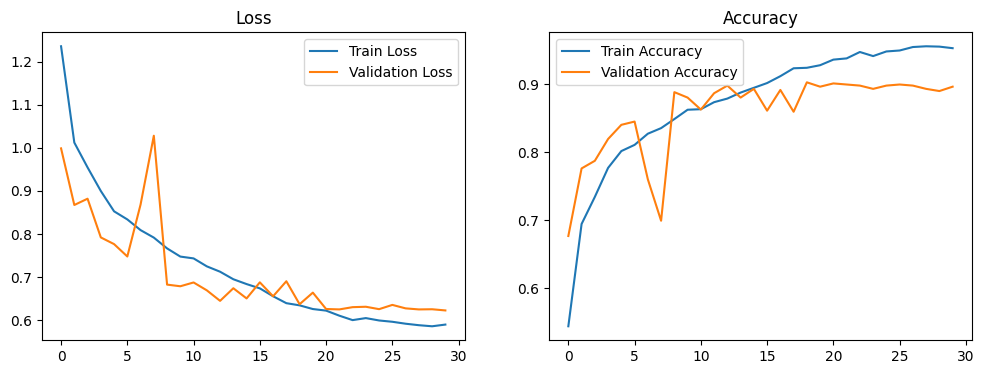

--- Training Meta Fold 4/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.1537 - acc: 0.6007 - val_loss: 0.9384 - val_acc: 0.7376
Epoch 2/30 - loss: 0.9743 - acc: 0.7140 - val_loss: 0.8948 - val_acc: 0.7616
Epoch 3/30 - loss: 0.9330 - acc: 0.7397 - val_loss: 0.8761 - val_acc: 0.7600
Epoch 4/30 - loss: 0.8935 - acc: 0.7688 - val_loss: 0.8141 - val_acc: 0.7984
Epoch 5/30 - loss: 0.8454 - acc: 0.8020 - val_loss: 0.8603 - val_acc: 0.7792
Epoch 6/30 - loss: 0.8131 - acc: 0.8190 - val_loss: 0.8068 - val_acc: 0.7984
Epoch 7/30 - loss: 0.8005 - acc: 0.8314 - val_loss: 0.7606 - val_acc: 0.8192
Epoch 8/30 - loss: 0.7734 - acc: 0.8468 - val_loss: 1.0830 - val_acc: 0.6704
Epoch 9/30 - loss: 0.7597 - acc: 0.8543 - val_loss: 0.7368 - val_acc: 0.8416
Epoch 10/30 - loss: 0.7372 - acc: 0.8623 - val_loss: 0.7180 - val_acc: 0.8592
Epoch 11/30 - loss: 0.7233 - acc: 0.8722 - val_loss: 0.7319 - val_acc: 0.8496
Epoch 12/30 - loss: 0.7158 - acc: 0.8759 - val_loss: 0.7030 - val_acc: 

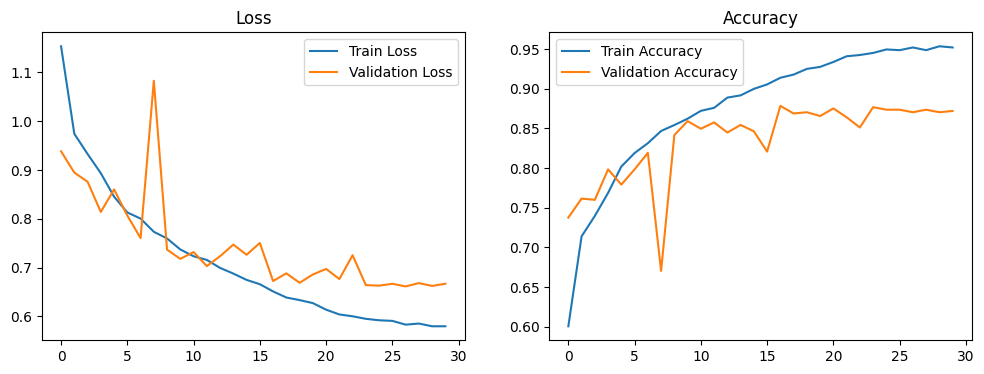

--- Training Meta Fold 5/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.2045 - acc: 0.5800 - val_loss: 1.0026 - val_acc: 0.6576
Epoch 2/30 - loss: 1.0121 - acc: 0.6976 - val_loss: 0.9036 - val_acc: 0.7328
Epoch 3/30 - loss: 0.9460 - acc: 0.7429 - val_loss: 1.1600 - val_acc: 0.5712
Epoch 4/30 - loss: 0.9091 - acc: 0.7668 - val_loss: 0.8315 - val_acc: 0.7920
Epoch 5/30 - loss: 0.8806 - acc: 0.7824 - val_loss: 0.7937 - val_acc: 0.8112
Epoch 6/30 - loss: 0.8491 - acc: 0.7967 - val_loss: 0.8040 - val_acc: 0.8096
Epoch 7/30 - loss: 0.8317 - acc: 0.8114 - val_loss: 0.7780 - val_acc: 0.8096
Epoch 8/30 - loss: 0.8024 - acc: 0.8254 - val_loss: 0.7360 - val_acc: 0.8448
Epoch 9/30 - loss: 0.7937 - acc: 0.8299 - val_loss: 0.7434 - val_acc: 0.8336
Epoch 10/30 - loss: 0.7599 - acc: 0.8519 - val_loss: 0.6904 - val_acc: 0.8496
Epoch 11/30 - loss: 0.7567 - acc: 0.8460 - val_loss: 0.7607 - val_acc: 0.8288
Epoch 12/30 - loss: 0.7473 - acc: 0.8538 - val_loss: 0.7455 - val_acc: 

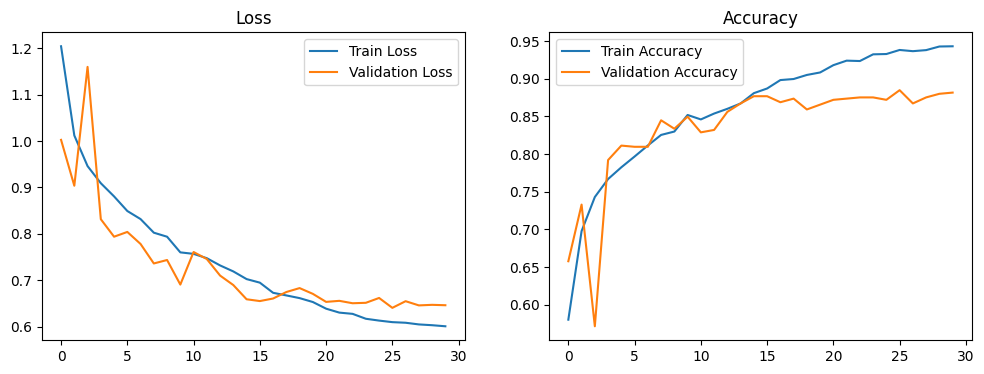

In [13]:
import numpy as np
import torch
from sklearn.model_selection import GroupKFold

meta_bagging_models = []
beatmap_ids_train = np.array(beatmap_ids_train)

# Initialize empty matrix for clean Out-Of-Fold CNN probability predictions
oof_cnn_predictions = np.zeros((len(X_train), num_classes), dtype=np.float32)

# Use GroupKFold so mapset difficulties stay grouped
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train_numerical, groups=beatmap_ids_train)):
    print(f"--- Training Meta Fold {fold + 1}/5 ---")

    # Split raw unaugmented fold data
    X_fold_train, y_fold_train = X_train[train_idx], y_train_numerical[train_idx]
    X_fold_val, y_fold_val = X_train[val_idx], y_train_numerical[val_idx]
    beatmap_ids_fold_train = beatmap_ids_train[train_idx]

    # Augment ONLY the training fold
    X_fold_train_aug, y_fold_train_aug, _ = augment_dataset(
        X_fold_train,
        y_fold_train,
        beatmap_ids_fold_train,
        augmentation_types={"horizontal", "vertical", "horizontal_vertical"}
    )

    # Convert validation fold to PyTorch Tensor (permuted to (B, C, L))
    X_fold_val = torch.as_tensor(X_fold_val, dtype=torch.float32).permute(0, 2, 1)
    y_fold_val = torch.as_tensor(y_fold_val, dtype=torch.long)

    X_fold_train_aug = X_fold_train_aug.permute(0, 2, 1)

    # Train CNN model for this fold
    model, history = train_and_evaluate(
        X_fold_train_aug,
        y_fold_train_aug,
        X_fold_val,
        y_fold_val,
        input_channels=X_fold_train_aug.shape[1],
        num_classes=num_classes,
        max_length=max_length,
        learning_rate=0.001,
        dropout_rate=0.5,
        l2_reg=0.001,
        batch_size=128,
        epochs=30,
        patience=8
    )
    plot_training_history(history)
    meta_bagging_models.append(model)

    # Generate Out-of-Fold predictions for the unaugmented validation set ONLY
    model.eval()
    with torch.no_grad():
        val_inputs = X_fold_val.to(device)
        logits = model(val_inputs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    # Store clean OOF predictions in the array
    oof_cnn_predictions[val_idx] = probs

In [14]:
import os

os.makedirs('models/bagged_models', exist_ok=True)

for i, model in enumerate(meta_bagging_models):
    torch.save(model.state_dict(), f'models/bagged_models/bagged_cnn_model_{i}.pth')

np.save("models/oof_cnn_predictions.npy", oof_cnn_predictions)
np.save("models/y_train_numerical.npy", y_train_numerical)
np.save("models/beatmap_ids_train.npy", np.array(beatmap_ids_train))

# XGBoost Meta Model

### Load Models and Data

In [10]:
from beatmap_classifier.classifier.cnn_model import CNNModel

model_kwargs = {
    "input_channels": 8,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5,
}

meta_bagging_models = load_pytorch_models(
    model_folder="models/bagged_models",
    model_class=CNNModel,
    model_kwargs=model_kwargs,
    device=device,
)

oof_cnn_predictions = np.load("models/oof_cnn_predictions.npy")
y_train_numerical = np.load("models/y_train_numerical.npy")

print(f"Loaded {len(meta_bagging_models)} CNN models")

Loaded 5 CNN models


### Test the bagging models

In [11]:
# Generate Test probabilities by averaging predictions across all fold models
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)
test_probs_list = []

for model in meta_bagging_models:
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        test_probs_list.append(probs)

bagged_test_predictions = np.mean(test_probs_list, axis=0)
bagged_test_predictions_numerical = np.argmax(bagged_test_predictions, axis=1)

score = accuracy_score(y_test_numerical, bagged_test_predictions_numerical)
cm = confusion_matrix(y_test_numerical, bagged_test_predictions_numerical)
report = classification_report(
    y_test_numerical,
    bagged_test_predictions_numerical,
    zero_division=0
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       191
           1       0.90      0.92      0.91       172
           2       0.88      0.89      0.89       178
           3       0.86      0.88      0.87       149
           4       0.82      0.80      0.81        92

    accuracy                           0.89       782
   macro avg       0.89      0.88      0.88       782
weighted avg       0.89      0.89      0.89       782

Confusion Matrix:
 [[177   0   8   3   3]
 [  1 158   3   2   8]
 [  3   3 159  11   2]
 [  1   3  11 131   3]
 [  1  11   0   6  74]]
Accuracy: 0.8938618925831202


### Setup

In [12]:
sql_feature_names = [
    "ar",
    "od",
    "circle_size",
    "star_rating",
    "bpm",
    "max_combo",
    "length_seconds",
    "object_count",
]

movement_feature_names = [
    "slider_ratio",
    "slider_length_std",
    "speed_std",
    "speed_change_std",
    "speed_change_max",
    "angle_std",
    "angle_mean",
    "rhythm_variance",
    "distance_mean",
    "speed_change_95th",
    "angle_90th",
    "sharp_turn_ratio",
]

cnn_feature_names = [
    "CNN_NM1",
    "CNN_NM2",
    "CNN_NM3",
    "CNN_NM4",
    "CNN_NM5",
]

additional_feature_names = (
    sql_feature_names +
    movement_feature_names
)

In [13]:
configs = [
    dict(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=1.0,
    ),
]

In [14]:
selected_features = [
    feature
    for feature in additional_feature_names
    if feature != "angle_90th"
]

additional_feature_groups = {
    "best": selected_features,
}

In [36]:
from sklearn.metrics import f1_score

def get_feature_indices(feature_names, selected_features):
    missing = [
        name for name in selected_features
        if name not in feature_names
    ]

    if missing:
        raise ValueError(f"Features not found: {missing}")

    return [feature_names.index(name) for name in selected_features]

def make_xgb(params):
    return XGBClassifier(
        random_state=42,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        **params
    )

def evaluate_feature_set(
    selected_features,
    X_additional_train,
    X_additional_test,
    oof_cnn_predictions,
    bagged_test_predictions,
    y_train,
    y_test,
    params,
    compare_feature_groups,
    indices
):

    if not compare_feature_groups:
        indices = [
            additional_feature_names.index(name)
            for name in selected_features
        ]

    X_meta_train = np.hstack([
        oof_cnn_predictions,
        X_additional_train[:, indices],
    ])

    X_meta_test = np.hstack([
        bagged_test_predictions,
        X_additional_test[:, indices],
    ])

    model = make_xgb(params)
    model.fit(X_meta_train, y_train)

    pred = model.predict(X_meta_test)

    acc = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    cm = confusion_matrix(y_test, pred)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "nm3_to_nm4": cm[2, 3],
        "nm4_to_nm3": cm[3, 2],
    }, model, pred

### Compare the XGBoost Classifiers within Feature Groups

In [39]:
from xgboost import XGBClassifier

feature_indices = {
    group_name: [
        additional_feature_names.index(feature)
        for feature in features
    ]
    for group_name, features in additional_feature_groups.items()
}

for group_name, indices in feature_indices.items():
    print("=" * 80)
    print(f"FEATURE GROUP: {group_name}")
    print("=" * 80)

    for i, params in enumerate(configs):

        results, model, pred = evaluate_feature_set(
            selected_features=None,
            X_additional_train=X_additional_train,
            X_additional_test=X_additional_test,
            oof_cnn_predictions=oof_cnn_predictions,
            bagged_test_predictions=bagged_test_predictions,
            y_train=y_train_numerical,
            y_test=y_test_numerical,
            params=configs[0],
            compare_feature_groups=True,
            indices=indices
        )

        report = classification_report(y_test_numerical, pred, output_dict=True, zero_division=0)
        print(f"Config {i}: accuracy={results["accuracy"] * 100:.2f}% | macro_f1={results["macro_f1"]:.4f}")

FEATURE GROUP: best
Config 0: accuracy=93.61% | macro_f1=0.9338


### Compare the XGBoost Classifiers by removing single features

In [48]:
import pandas as pd

all_features = additional_feature_groups["best"]

baseline, meta_model, y_pred_meta = evaluate_feature_set(
    selected_features=all_features,
    X_additional_train=X_additional_train,
    X_additional_test=X_additional_test,
    oof_cnn_predictions=oof_cnn_predictions,
    bagged_test_predictions=bagged_test_predictions,
    y_train=y_train_numerical,
    y_test=y_test_numerical,
    params=configs[0],
    compare_feature_groups=False,
    indices=None
)

with open("models/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

print("Baseline:")
print(baseline)

baseline_acc = baseline["accuracy"]
baseline_f1 = baseline["macro_f1"]

array_results = []

for removed_feature in all_features:

    remaining_features = [
        feature
        for feature in all_features
        if feature != removed_feature
    ]

    results, _, _ = evaluate_feature_set(
        selected_features=remaining_features,
        X_additional_train=X_additional_train,
        X_additional_test=X_additional_test,
        oof_cnn_predictions=oof_cnn_predictions,
        bagged_test_predictions=bagged_test_predictions,
        y_train=y_train_numerical,
        y_test=y_test_numerical,
        params=configs[0],
        compare_feature_groups=False,
        indices=None
    )

    dict_results = {
        "removed": removed_feature,
        "accuracy": results["accuracy"],
        "macro_f1": results["macro_f1"],
        "acc_delta": results["accuracy"] - baseline_acc,
        "f1_delta": results["macro_f1"] - baseline_f1,
        "nm3_to_nm4": results["nm3_to_nm4"],
        "nm4_to_nm3": results["nm4_to_nm3"]
    }

    array_results.append(dict_results)

results_df = pd.DataFrame(array_results)

results_df = results_df.sort_values(
    "acc_delta",
    ascending=False
)

print(results_df.to_string(index=False))

Baseline:
{'accuracy': 0.9360613810741688, 'macro_f1': 0.9338283663262056, 'nm3_to_nm4': np.int64(7), 'nm4_to_nm3': np.int64(8)}
          removed  accuracy  macro_f1  acc_delta  f1_delta  nm3_to_nm4  nm4_to_nm3
   length_seconds  0.933504  0.930754  -0.002558 -0.003074           8           7
       angle_mean  0.933504  0.930829  -0.002558 -0.002999           8           9
 sharp_turn_ratio  0.932225  0.930239  -0.003836 -0.003589           8           9
     object_count  0.932225  0.929408  -0.003836 -0.004420           8           9
     slider_ratio  0.930946  0.928902  -0.005115 -0.004926           8           9
        speed_std  0.930946  0.928060  -0.005115 -0.005769           9           9
  rhythm_variance  0.930946  0.928306  -0.005115 -0.005522           6           9
        angle_std  0.929668  0.926749  -0.006394 -0.007079           9           9
      circle_size  0.929668  0.926444  -0.006394 -0.007384           8           9
               ar  0.929668  0.927162  -0

### Testing our best (aka baseline) XGBoost Model

In [49]:
indices = [
    additional_feature_names.index(name)
    for name in selected_features
]

X_meta_train = np.hstack([
    oof_cnn_predictions,
    X_additional_train[:, indices],
])

X_meta_test = np.hstack([
    bagged_test_predictions,
    X_additional_test[:, indices],
])

test_acc = accuracy_score(y_test_numerical, y_pred_meta)

print(f"--- XGBoost Meta-Model Performance ---")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test_numerical, y_pred_meta, target_names=["NM1", "NM2", "NM3", "NM4", "NM5"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test_numerical, y_pred_meta))

--- XGBoost Meta-Model Performance ---
Final Test Accuracy: 93.61%

Classification Report:
              precision    recall  f1-score   support

         NM1       0.97      0.95      0.96       191
         NM2       0.97      0.94      0.95       172
         NM3       0.92      0.92      0.92       178
         NM4       0.91      0.91      0.91       149
         NM5       0.87      0.98      0.92        92

    accuracy                           0.94       782
   macro avg       0.93      0.94      0.93       782
weighted avg       0.94      0.94      0.94       782

Confusion Matrix:
[[182   0   4   3   2]
 [  1 161   2   3   5]
 [  1   3 164   7   3]
 [  2   1   8 135   3]
 [  1   1   0   0  90]]


# Analysis

In [50]:
importance = meta_model.feature_importances_
meta_model_features = cnn_feature_names + selected_features

for name, value in sorted(
    zip(meta_model_features, importance),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{name:30s} {value:.4f}")

CNN_NM1                        0.1916
CNN_NM3                        0.1586
CNN_NM2                        0.1560
CNN_NM4                        0.1446
CNN_NM5                        0.1030
bpm                            0.0385
sharp_turn_ratio               0.0362
distance_mean                  0.0325
slider_ratio                   0.0234
slider_length_std              0.0185
angle_mean                     0.0151
length_seconds                 0.0098
star_rating                    0.0097
angle_std                      0.0096
od                             0.0083
ar                             0.0081
object_count                   0.0079
speed_std                      0.0077
max_combo                      0.0073
rhythm_variance                0.0068
circle_size                    0.0067
speed_change_std               0.0000
speed_change_max               0.0000
speed_change_95th              0.0000


In [51]:
feature_names = [
    "AR",
    "OD",
    "Circle Size",
    "Star Rating",
    "BPM",
    "Max Combo",
    "Length (s)",
    "Object Count",
]

print("\nRaw Additional feature ranges:")
print("-" * 70)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    print(
        f"{name:15s} "
        f"min={np.min(values):8.2f}  "
        f"max={np.max(values):8.2f}  "
        f"mean={np.mean(values):8.2f}  "
        f"median={np.median(values):8.2f}"
    )

print("\nRaw Additional feature percentiles:")
print("-" * 90)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    p = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])

    print(
        f"{name:15s} "
        f"1%={p[0]:8.2f}  "
        f"5%={p[1]:8.2f}  "
        f"25%={p[2]:8.2f}  "
        f"50%={p[3]:8.2f}  "
        f"75%={p[4]:8.2f}  "
        f"95%={p[5]:8.2f}  "
        f"99%={p[6]:8.2f}"
    )


Raw Additional feature ranges:
----------------------------------------------------------------------
AR              min=    6.80  max=   10.00  mean=    9.50  median=    9.50
OD              min=    5.00  max=   10.00  mean=    8.87  median=    9.00
Circle Size     min=    2.00  max=    6.40  mean=    4.01  median=    4.00
Star Rating     min=    4.28  max=   10.12  mean=    6.79  median=    6.73
BPM             min=   50.00  max=  363.86  mean=  184.48  median=  185.00
Max Combo       min=  252.00  max=10215.00  mean= 1527.35  median= 1449.00
Length (s)      min=   18.29  max= 1645.53  mean=  192.91  median=  194.44
Object Count    min=  156.00  max= 6310.00  mean= 1086.77  median= 1023.00

Raw Additional feature percentiles:
------------------------------------------------------------------------------------------
AR              1%=    9.00  5%=    9.20  25%=    9.40  50%=    9.50  75%=    9.60  95%=    9.80  99%=   10.00
OD              1%=    7.50  5%=    8.00  25%=    8.50  50

In [52]:
bpm = raw_additional_features_array[:, 4]
for threshold in [300, 400, 500, 600, 800, 1000]:
    count = np.sum(bpm > threshold)

    print(
        f"bpm > {threshold:4d}: "
        f"{count:6d} "
        f"({count / len(bpm) * 100:.3f}%)"
    )

bpm >  300:      8 (0.205%)
bpm >  400:      0 (0.000%)
bpm >  500:      0 (0.000%)
bpm >  600:      0 (0.000%)
bpm >  800:      0 (0.000%)
bpm > 1000:      0 (0.000%)


In [53]:
sequence_lengths = np.array([len(seq) for seq in X])

print("Number of beatmaps:", len(sequence_lengths))
print("Min:", sequence_lengths.min())
print("Median:", np.median(sequence_lengths))
print("Mean:", sequence_lengths.mean())
print("75th:", np.percentile(sequence_lengths, 75))
print("90th:", np.percentile(sequence_lengths, 90))
print("95th:", np.percentile(sequence_lengths, 95))
print("99th:", np.percentile(sequence_lengths, 99))
print("Max:", sequence_lengths.max())

Number of beatmaps: 3908
Min: 155
Median: 1022.0
Mean: 1085.7730296827021
75th: 1247.0
90th: 1578.3000000000002
95th: 1874.0
99th: 2547.0199999999977
Max: 6309
